# ***WEEK 1*** - Data Collection and Exploration

***DATASET FROM KAGGLE***

## Loading Kaggle Football Dataset
The dataset contains information about:
- Player market value
- Player performances
- Player injuries

In [49]:
# Extract the Kaggle ZIP dataset containing football market value,
# performance, and injury data
import zipfile

with zipfile.ZipFile("/content/archive(tm).zip", 'r') as zip_ref:
    zip_ref.extractall("football_data")

In [50]:
import os
os.listdir("football_data/player_market_value")

['player_market_value.csv']

In [51]:
# Load player market value dataset

In [52]:
import pandas as pd

df_market = pd.read_csv("football_data/player_market_value/player_market_value.csv")

df_market.head()

,player_id,date_unix,value
0,1000135,2023-12-19,100000.0
1,1000135,2024-06-23,100000.0
2,10,2005-01-06,9000000.0
3,10,2008-06-03,20000000.0
4,10,2009-08-29,12000000.0


In [53]:
import pandas as pd
#df_market = pd.read_csv("football_data/player_market_value/player_market_value.csv")
df_perf = pd.read_csv("football_data/player_performances/player_performances.csv")
df_injury = pd.read_csv("football_data/player_injuries/player_injuries.csv")
#df_market.head()
df_perf.head()
df_injury.head()

,player_id,season_name,injury_reason,from_date,end_date,days_missed,games_missed
0,10,15/16,Hand injury,2016-04-19,2016-04-29,11.0,2
1,10,15/16,Thigh problems,2015-12-18,2015-12-31,14.0,1
2,10,15/16,Capsular injury,2015-11-11,2015-11-21,11.0,0
3,10,15/16,Rest,2015-11-04,2015-11-06,3.0,1
4,10,15/16,Hamstring injury,2015-08-20,2015-10-08,50.0,10


In [54]:
df_market.info()
df_perf.info()
df_injury.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 901429 entries, 0 to 901428
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   player_id  901429 non-null  int64  
 1   date_unix  901429 non-null  object 
 2   value      901429 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 20.6+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1878719 entries, 0 to 1878718
Data columns (total 20 columns):
 #   Column               Dtype  
---  ------               -----  
 0   player_id            int64  
 1   season_name          object 
 2   competition_id       object 
 3   competition_name     object 
 4   team_id              int64  
 5   team_name            object 
 6   nb_in_group          int64  
 7   nb_on_pitch          int64  
 8   goals                float64
 9   assists              int64  
 10  own_goals            int64  
 11  subed_in             int64  
 12  subed_out            int64  

In [55]:
# Check for missing values
df_market.isnull().sum()
df_perf.isnull().sum()
df_injury.isnull().sum()

,0
player_id,0
season_name,0
injury_reason,0
from_date,22
end_date,1523
days_missed,22
games_missed,0


In [56]:
os.listdir("football_data/player_market_value")

['player_market_value.csv']

## Sentiment Analysis

Sentiment analysis is performed using the VADER Sentiment Analyzer to understand the polarity of football-related textual data.  
The compound sentiment score ranges from -1 (negative sentiment) to +1 (positive sentiment).

In [57]:
pip install vaderSentiment tweepy

In [58]:
sample_texts = [
    "He is playing amazingly this season!",
    "Worst performance I have ever seen.",
    "Solid transfer, good signing.",
    "Terrible injury setback for the team."
]

results = []

for text in sample_texts:
    score = analyzer.polarity_scores(text)
    results.append({
        "text": text,
        "compound_score": score["compound"]
    })

import pandas as pd
df_sentiment = pd.DataFrame(results)
df_sentiment

,text,compound_score
0,He is playing amazingly this season!,0.2714
1,Worst performance I have ever seen.,-0.6249
2,"Solid transfer, good signing.",0.5423
3,Terrible injury setback for the team.,-0.7096


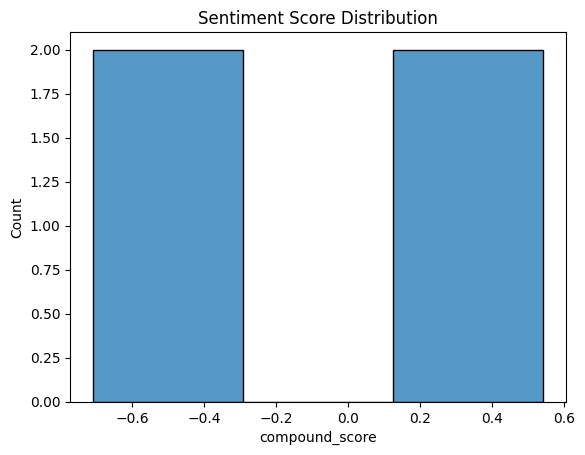

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_sentiment["compound_score"])
plt.title("Sentiment Score Distribution")
plt.show()

In [60]:
import pandas as pd
df_sentiment.to_csv("data/raw/sentiment_data.csv", index=False)

In [61]:
df_injury.info()
df_injury.describe()
df_injury.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143195 entries, 0 to 143194
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   player_id      143195 non-null  int64  
 1   season_name    143195 non-null  object 
 2   injury_reason  143195 non-null  object 
 3   from_date      143173 non-null  object 
 4   end_date       141672 non-null  object 
 5   days_missed    143173 non-null  float64
 6   games_missed   143195 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 7.6+ MB


,0
player_id,0
season_name,0
injury_reason,0
from_date,22
end_date,1523
days_missed,22
games_missed,0


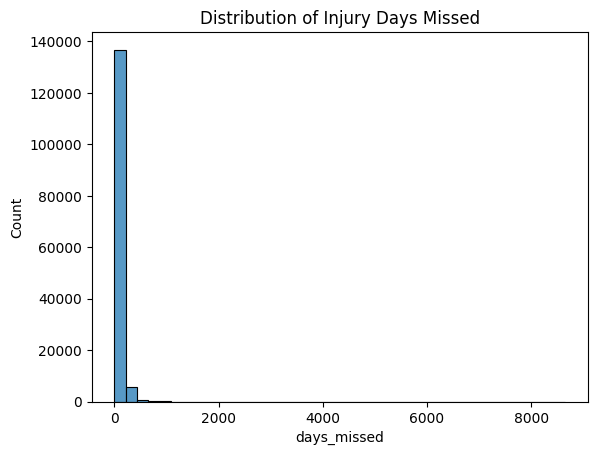

In [62]:
sns.histplot(df_injury['days_missed'], bins=40)
plt.title("Distribution of Injury Days Missed")
plt.show()

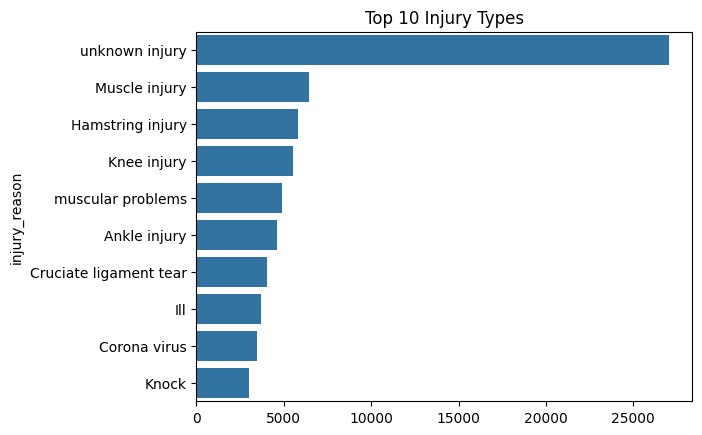

In [63]:
top_injuries = df_injury['injury_reason'].value_counts().head(10)

sns.barplot(x=top_injuries.values, y=top_injuries.index)
plt.title("Top 10 Injury Types")
plt.show()

In [64]:
df_injury['from_date'] = pd.to_datetime(df_injury['from_date'])
df_injury['end_date'] = pd.to_datetime(df_injury['end_date'])

In [65]:
df_perf.columns

Index(['player_id', 'season_name', 'competition_id', 'competition_name',
       'team_id', 'team_name', 'nb_in_group', 'nb_on_pitch', 'goals',
       'assists', 'own_goals', 'subed_in', 'subed_out', 'yellow_cards',
       'second_yellow_cards', 'direct_red_cards', 'penalty_goals',
       'minutes_played', 'goals_conceded', 'clean_sheets'],
      dtype='object')

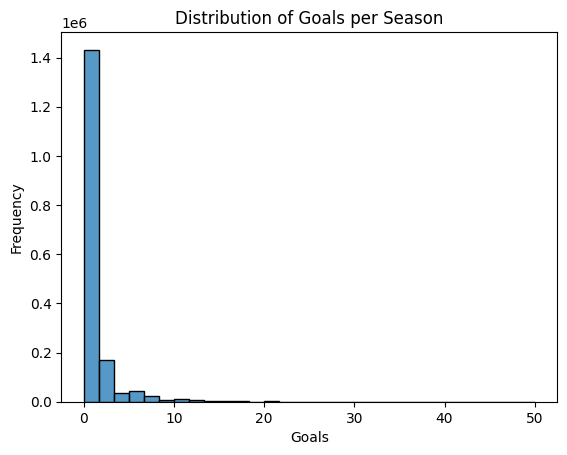

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_perf['goals'], bins=30)
plt.title("Distribution of Goals per Season")
plt.xlabel("Goals")
plt.ylabel("Frequency")
plt.show()

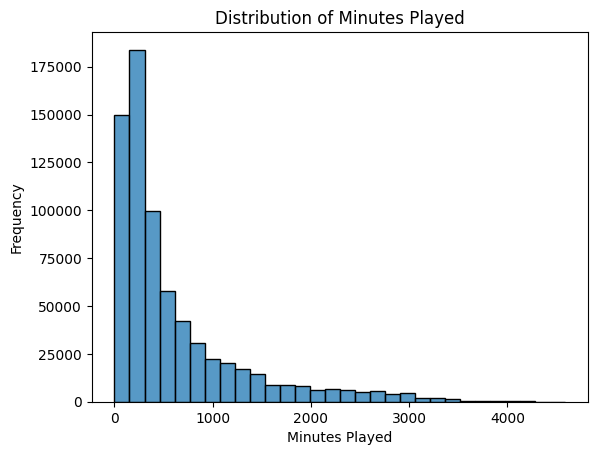

In [67]:
sns.histplot(df_perf['minutes_played'], bins=30)
plt.title("Distribution of Minutes Played")
plt.xlabel("Minutes Played")
plt.ylabel("Frequency")
plt.show()

Most players score fewer than 5 goals per season.

A small number of players have extremely high goal counts.

Minutes played varies significantly across players.

Assist distribution is right-skewed.

*In Week 1, multi-source football datasets were successfully collected, including market value data, player performance statistics, injury records, and sentiment analysis results. Initial exploratory data analysis was conducted to understand data structure, distributions, and missing values. Visualizations revealed significant variability in player performance metrics and market valuations, laying the foundation for future feature engineering and predictive modeling.

# ***WEEK 2*** – Data Cleaning and Feature Engineering

In [68]:
# Convert date column to datetime
df_market['date_unix'] = pd.to_datetime(df_market['date_unix'])

In [69]:
df_injury['from_date'] = pd.to_datetime(df_injury['from_date'])
df_injury['end_date'] = pd.to_datetime(df_injury['end_date'])

In [70]:
df_market = df_market.drop_duplicates()
df_perf = df_perf.drop_duplicates()
df_injury = df_injury.drop_duplicates()

In [71]:
df_perf.isnull().sum()
df_perf.fillna(0, inplace=True)
df_perf.head()

,player_id,season_name,competition_id,competition_name,team_id,team_name,nb_in_group,nb_on_pitch,goals,assists,own_goals,subed_in,subed_out,yellow_cards,second_yellow_cards,direct_red_cards,penalty_goals,minutes_played,goals_conceded,clean_sheets
0,1,08/09,OBLG,NOFV-Oberliga Süd,4825,FC Eilenburg,9,9,0.0,0,0,0,2,0,0,1,0,0.0,0,0
1,1,07/08,RS,Regionalliga Süd,1526,FSV Ludwigshafen Oggersheim,22,22,1.0,0,0,3,8,1,0,0,0,1580.0,0,0
2,1,06/07,L2,2. Bundesliga,996,TuS Koblenz,10,4,0.0,0,0,4,0,0,0,0,0,0.0,0,0
3,1,06/07,DFB,DFB-Pokal,996,TuS Koblenz,1,0,0.0,0,0,0,0,0,0,0,0,0.0,0,0
4,1,05/06,L2,2. Bundesliga,66,SpVgg Unterhaching,26,14,1.0,1,0,12,1,1,0,0,0,388.0,0,0


In [72]:
injury_summary = df_injury.groupby('player_id')['days_missed'].sum().reset_index()
injury_summary.rename(columns={'days_missed': 'total_days_missed'}, inplace=True)

In [73]:
performance_summary = df_perf.groupby('player_id').agg({
    'goals': 'sum',
    'assists': 'sum',
    'minutes_played': 'sum'
}).reset_index()

In [74]:
latest_market = df_market.sort_values('date_unix').groupby('player_id').tail(1)

## Final Dataset

The cleaned and merged dataset combines information from:

- Player market values
- Player performance statistics
- Player injury history



In [75]:
final_df = latest_market.merge(performance_summary, on='player_id', how='left')
final_df = final_df.merge(injury_summary, on='player_id', how='left')

In [76]:
final_df['total_days_missed'] = final_df['total_days_missed'].fillna(0)

In [77]:
final_df.head()
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69441 entries, 0 to 69440
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   player_id          69441 non-null  int64         
 1   date_unix          69441 non-null  datetime64[ns]
 2   value              69441 non-null  float64       
 3   goals              69123 non-null  float64       
 4   assists            69123 non-null  float64       
 5   minutes_played     69123 non-null  float64       
 6   total_days_missed  69441 non-null  float64       
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 3.7 MB


In [78]:
final_df[['goals', 'assists', 'minutes_played']] = \
final_df[['goals', 'assists', 'minutes_played']].fillna(0)

In [79]:
final_df.isnull().sum()

,0
player_id,0
date_unix,0
value,0
goals,0
assists,0
minutes_played,0
total_days_missed,0


# DOWNLOADED THE CLEANED MERGED DATASET AS **CSV** FILE

In [80]:
final_df.to_csv("cleaned_merged_dataset.csv", index=False)

In [81]:
from google.colab import files
files.download("cleaned_merged_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>